# Chatbot Failure Analysis

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.dates as mdates
import re, warnings, seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
import sys
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='tab10')

_nb = globals().get('__vsc_ipynb_file__', None)
if _nb:
    REPO_ROOT = Path(_nb).parent.parent
else:
    _cwd = Path.cwd()
    REPO_ROOT = _cwd if (_cwd / 'gcp_config.py').exists() else _cwd.parent

OUT_DIR = REPO_ROOT / 'data'
OUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = OUT_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR = OUT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

sys.path.insert(0, str(REPO_ROOT))
from gcp_config import PROJECT_ID, bq_table
from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

df = client.query(f"""
    SELECT
        d.conversation_id,
        DATE(d.conversation_start_date)        AS conversation_date,
        d.client_message_count,
        d.total_message_count,
        d.was_escalated_to_agent,
        d.rating_score,
        d.detected_language,
        d.conversation_text_client_original    AS conversation_text,
        ff.is_confirmed_failure,
        ff.is_probable_failure,
        ff.is_suspected_failure,
        ff.is_any_failure,
        ff.failure_type,
        ff.requested_agent,
        ff.is_probable_repetition_signal,
        ff.is_probable_agent_signal
    FROM `{bq_table('conversation_docs')}` d
    LEFT JOIN `{bq_table('failure_flags')}` ff USING (conversation_id)
""").to_dataframe()
df['conversation_date'] = pd.to_datetime(df['conversation_date'])
df['week']  = df['conversation_date'].dt.to_period('W').dt.start_time
df['month'] = df['conversation_date'].dt.to_period('M').dt.start_time
df['is_failure'] = df['is_any_failure'].fillna(False)
df['rating'] = df['rating_score'].map({-1: '\U0001f61e', 0: '', 1: '\U0001f60a'}).fillna('')

fail_rate = client.query(f"""
    SELECT
        cluster_id,
        n_chunks,
        total_conversations                             AS total,
        headline_failures                               AS failures,
        ROUND(chunk_headline_failure_rate_pct, 1)       AS fail_rate,
        agent_request_unserved                          AS escalations,
        ROUND(chunk_escalation_rate_pct, 1)             AS esc_rate,
        confirmed_failures                              AS neg_ratings,
        abandoned_inquiry                               AS long_unresolved,
        ROUND(avg_client_messages, 2)                   AS avg_client_msgs
    FROM `{bq_table('failure_by_chunk_cluster')}`
    ORDER BY chunk_headline_failure_rate_pct DESC
""").to_dataframe()

TRACK    = 'multilingual'
lbl      = 'Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-d)'

df_chunks = client.query(f"""
    SELECT
        chunk_uid,
        conversation_id,
        cluster_id,
        is_noise,
        original_chunk_text AS chunk_text
    FROM `{bq_table('chunk_cluster_labels')}`
    ORDER BY chunk_uid
""").to_dataframe()
df_chunks = df_chunks.merge(
    df[['conversation_id', 'is_failure']],
    on='conversation_id',
    how='left',
)
df_chunks['is_failure'] = df_chunks['is_failure'].fillna(False)

n_clusters = fail_rate['cluster_id'].nunique()
print(f"Conversations: {len(df):,} | chunks: {len(df_chunks):,} | clusters: {n_clusters}")
print(f"Failure flags: {df.is_failure.sum():,} headline failures ({100*df.is_failure.mean():.1f}%)")
print(f"  T1 confirmed (rating -1): {df['rating_score'].eq(-1).sum():,}")
print(f"  T2 probable (repetition or unserved agent, unrated): {df['is_probable_failure'].fillna(False).sum():,}")
if 'is_probable_repetition_signal' in df.columns:
    print(f"    with repetition loop signal: {df['is_probable_repetition_signal'].fillna(False).sum():,}")
    print(f"    with unserved agent-request signal: {df['is_probable_agent_signal'].fillna(False).sum():,}")
    both = df['is_probable_repetition_signal'].fillna(False) & df['is_probable_agent_signal'].fillna(False)
    print(f"    overlap (both): {both.sum():,}")
print(f"\nChunk counts per cluster (n_chunks column): min={fail_rate['n_chunks'].min()}, max={fail_rate['n_chunks'].max()}, total={fail_rate['n_chunks'].sum():,}")

Conversations: 46,445 | chunks: 169,709 | clusters: 24
Failure flags: 3,491 headline failures (7.5%)
  T1 confirmed (rating -1): 2,245
  T2 probable (repetition or unserved agent, unrated): 1,246
    with repetition loop signal: 345
    with unserved agent-request signal: 1,002
    overlap (both): 101

Chunk counts per cluster (n_chunks column): min=3143, max=10609, total=149,363


In [2]:
titles_df = client.query(f"""
    SELECT cluster_id, cluster_title
    FROM `{bq_table('chunk_cluster_descriptions')}`
    ORDER BY cluster_id
""").to_dataframe()
fail_rate = fail_rate.merge(titles_df, on='cluster_id', how='left')
fail_rate['cluster_title'] = fail_rate['cluster_title'].fillna(fail_rate['cluster_id'].astype(str))
print(f"Loaded {len(titles_df)} cluster titles")

Loaded 24 cluster titles


## 1. Define failure signals

In [3]:
ESCALATION_RE = re.compile(
    r'\b(agent|human|live (chat|support|agent|person)|speak to (someone|a person|support)|'
    r'real person|talk to (someone|a human|an agent)|connect me|escalate|supervisor|manager|'
    r'talk to agent|need help from|customer service)\b',
    re.IGNORECASE
)

df['flag_escalation']      = df['requested_agent'].fillna(False).astype(bool)
df['flag_negative_rating'] = (df['rating_score'] == -1)

p75 = df['client_message_count'].quantile(0.75)
df['flag_long_unresolved'] = (df['client_message_count'] > p75) & (df['rating_score'] == 0)

df['flag_short_abandon']   = (df['client_message_count'] == 1) & (df['rating_score'] == 0)

df['is_failure'] = df['is_any_failure'].fillna(False)
df['flag_escalation_text_regex'] = df['conversation_text'].apply(
    lambda t: bool(ESCALATION_RE.search(str(t))))

print(f'\n{lbl}:')
print(f'  flag_long_unresolved threshold (p75 client messages): {p75:.0f}')
for col in ['flag_escalation', 'flag_negative_rating', 'flag_long_unresolved', 'flag_short_abandon', 'is_failure']:
    n = df[col].sum()
    print(f'  {col:30s}: {n:5d}  ({100*n/len(df):.1f}%)')
ct = pd.crosstab(
    df['requested_agent'].fillna(False).astype(bool),
    df['was_escalated_to_agent'].fillna(False).astype(bool),
    rownames=['requested_agent (BQ regex on original text)'],
    colnames=['was_escalated_to_agent'],
)
print('\n  Crosstab: BQ regex agent-request (original text) vs Agent actually joined:')
print(ct.to_string())
print()
print('  Definitions:')
print(f'    flag_long_unresolved = client_message_count > {p75:.0f} AND rating_score == 0')
print( '    flag_short_abandon   = client_message_count == 1 AND rating_score == 0')
print( '    is_failure           = BQ is_any_failure (T1 or T2) — canonical headline metric')
print( '    flag_escalation      = failure_flags.requested_agent (BQ regex field)')
print( '  Note: flag_long_unresolved and flag_short_abandon are exploratory behavioural')
print( '  signals only. The headline failure rate is driven by is_failure from BigQuery.')



Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-d):
  flag_long_unresolved threshold (p75 client messages): 9
  flag_escalation               : 13171  (28.4%)
  flag_negative_rating          :  2245  (4.8%)
  flag_long_unresolved          :  9807  (21.1%)
  flag_short_abandon            : 12801  (27.6%)
  is_failure                    :  3491  (7.5%)

  Crosstab: BQ regex agent-request (original text) vs Agent actually joined:
was_escalated_to_agent                       False  True 
requested_agent (BQ regex on original text)              
False                                        28121   5153
True                                          1156  12015

  Definitions:
    flag_long_unresolved = client_message_count > 9 AND rating_score == 0
    flag_short_abandon   = client_message_count == 1 AND rating_score == 0
    is_failure           = BQ is_any_failure (T1 or T2) — canonical headline metric
    flag_escalation      = failure_flags.requested_

## 2. Failure rate per cluster


Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-d) — Failure rates per cluster (worst → best):
 cluster_id                          cluster_title  total  failures  fail_rate  escalations  esc_rate  neg_ratings
         20      Website Down HTTP Error Diagnosis   4607       656       19.2           98      56.2          523
          9          Cloudflare CDN and DNS Issues   2348       337       18.7           45      64.6          276
          7       Free Trial and Plan Restrictions   3475       526       18.0          214      32.6          274
         10    SSL Certificate Installation Errors   2341       315       16.5           42      57.8          259
         11       Domain Purchase and Registration   4945       575       16.5           90      47.3          447
         21 Website Disappearing Visibility Issues   3626       469       15.6           83      56.0          367
          6      WooCommerce eCommerce Store Setup   2536      

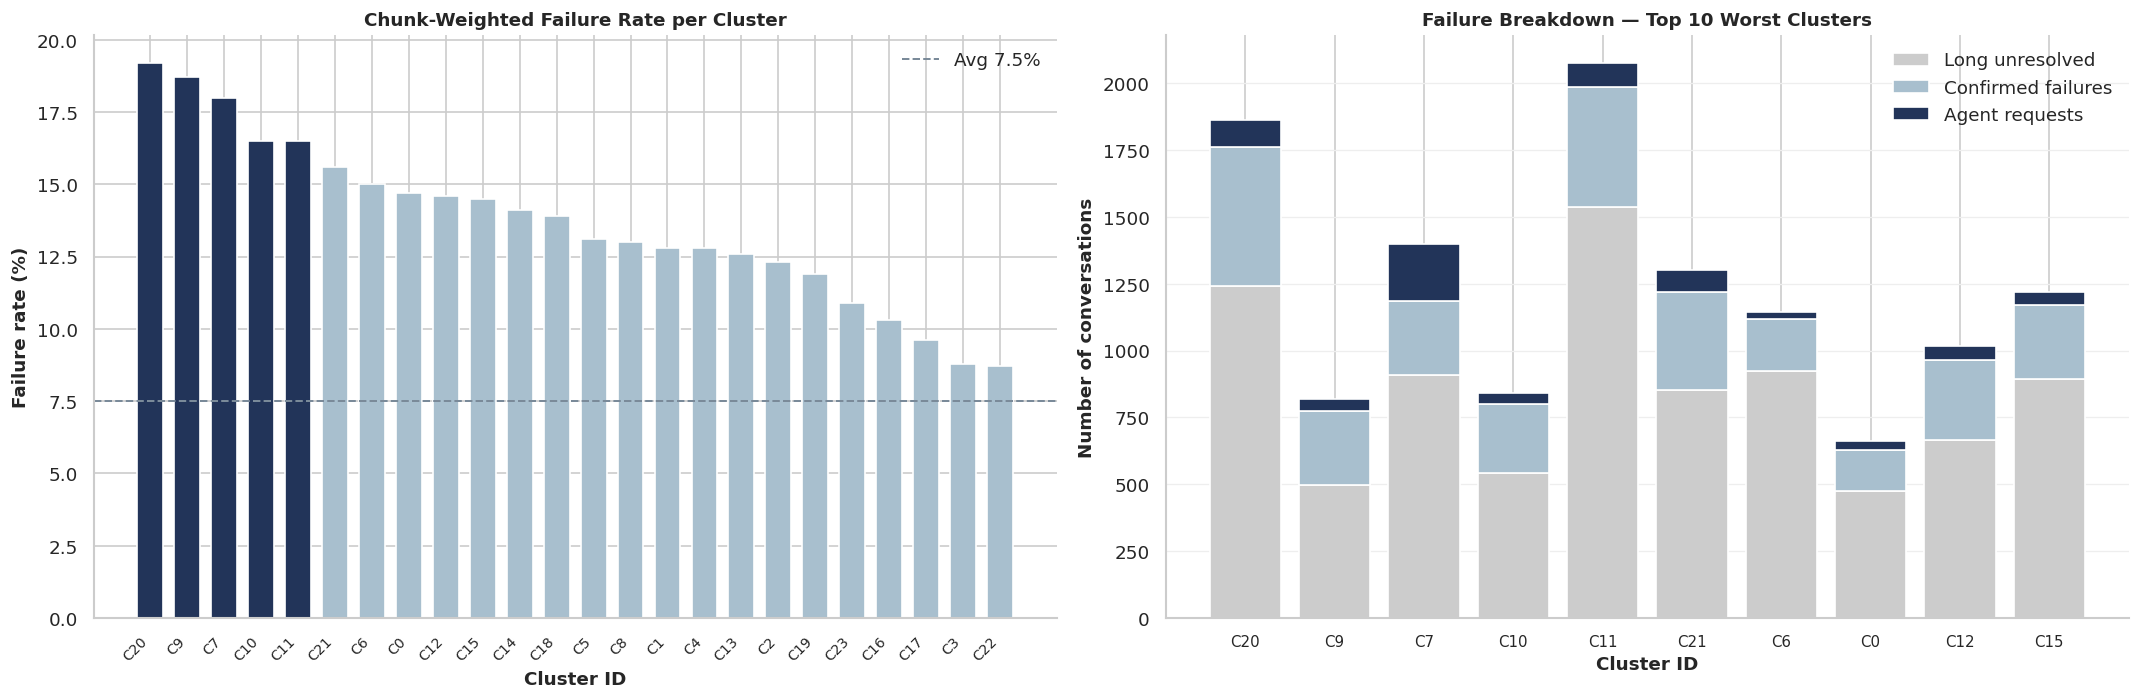

In [6]:
NAVY      = '#223459'
STEEL     = '#A8BFCE'
LGREY     = '#CCCCCC'
BLACK     = '#111111'
GREY      = '#7A8A99'
LIGHTGREY = '#CCCCCC'

fail_rate.to_csv(RESULTS_DIR / f'failure_by_cluster_{TRACK}.csv', index=False)

print(f'\n{lbl} — Failure rates per cluster (worst → best):')
print(fail_rate[['cluster_id', 'cluster_title', 'total', 'failures', 'fail_rate',
                  'escalations', 'esc_rate', 'neg_ratings']].to_string(index=False))

HEADLINE_AVG = 7.5
poster_df = fail_rate.sort_values('fail_rate', ascending=True).reset_index(drop=True)

def poster_label(row):
    title = row['cluster_title']
    truncated = title[:38] + '…' if len(title) > 38 else title
    return f"C{int(row['cluster_id'])}: {truncated}"

poster_df['label'] = poster_df.apply(poster_label, axis=1)
TOP5_THRESHOLD = poster_df['fail_rate'].nlargest(5).min()
poster_colors  = [NAVY if v >= TOP5_THRESHOLD else STEEL for v in poster_df['fail_rate']]

fig_p, ax_p = plt.subplots(figsize=(14, 10))
fig_p.patch.set_facecolor('white')
ax_p.set_facecolor('white')
ax_p.grid(False)
ax_p.barh(range(len(poster_df)), poster_df['fail_rate'], color=poster_colors, height=0.72)
for i, val in enumerate(poster_df['fail_rate']):
    ax_p.text(val + 0.25, i, f'{val:.1f}%', va='center', fontsize=9.5, color=BLACK, fontweight='bold')
ax_p.axvline(HEADLINE_AVG, color=GREY, ls='--', lw=1.2, label=f'Headline avg {HEADLINE_AVG:.1f}%')
ax_p.legend(frameon=False, fontsize=10, loc='lower right')
ax_p.set_yticks(range(len(poster_df)))
ax_p.set_yticklabels(poster_df['label'], fontsize=10.5, color=BLACK)
for tick in ax_p.get_yticklabels():
    tick.set_fontweight('bold')
ax_p.set_xlabel('Chunk-weighted headline failure rate (%)', fontsize=11, color=BLACK, fontweight='bold')
ax_p.set_title('Chatbot Failure Rate by Intent Cluster', fontsize=13, fontweight='bold', color=BLACK, pad=14)
ax_p.set_xlim(0, max(24, poster_df['fail_rate'].max() + 3))
ax_p.tick_params(axis='x', colors=BLACK, labelsize=11, length=5, width=1.2)
ax_p.tick_params(axis='y', colors=BLACK, labelsize=10.5, length=0)
for sp in ['top', 'right', 'left']:
    ax_p.spines[sp].set_visible(False)
ax_p.spines['bottom'].set_color(LIGHTGREY)
ax_p.spines['bottom'].set_linewidth(1.2)
fig_p.tight_layout()
fig_p.savefig(FIGURES_DIR / f'failure_by_cluster_{TRACK}.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig_p)
print(f'Saved (poster): failure_by_cluster_{TRACK}.png')

rate_df = fail_rate.sort_values('fail_rate', ascending=False).reset_index(drop=True)
top10   = rate_df.head(10).copy()
bar_colors_l = [NAVY if v >= TOP5_THRESHOLD else STEEL for v in rate_df['fail_rate']]

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('white')

ax_l.set_facecolor('white')
ax_l.bar(range(len(rate_df)), rate_df['fail_rate'], color=bar_colors_l, width=0.7)
ax_l.axhline(HEADLINE_AVG, color=GREY, ls='--', lw=1.2, label=f'Avg {HEADLINE_AVG:.1f}%')
ax_l.set_xticks(range(len(rate_df)))
ax_l.set_xticklabels([f"C{int(c)}" for c in rate_df['cluster_id']], rotation=45, ha='right', fontsize=8.5)
ax_l.set_xlabel('Cluster ID', fontsize=11, fontweight='bold')
ax_l.set_ylabel('Failure rate (%)', fontsize=11, fontweight='bold')
ax_l.set_title('Chunk-Weighted Failure Rate per Cluster', fontsize=11, fontweight='bold')
ax_l.legend(frameon=False)
sns.despine(ax=ax_l)

x = np.arange(len(top10))
ax_r.set_facecolor('white')
ax_r.bar(x, top10['long_unresolved'], color=LGREY,  label='Long unresolved')
ax_r.bar(x, top10['neg_ratings'],     color=STEEL,  label='Confirmed failures',
         bottom=top10['long_unresolved'])
ax_r.bar(x, top10['escalations'],     color=NAVY,   label='Agent requests',
         bottom=top10['long_unresolved'] + top10['neg_ratings'])
ax_r.set_xticks(x)
ax_r.set_xticklabels([f"C{int(c)}" for c in top10['cluster_id']], fontsize=9)
ax_r.set_xlabel('Cluster ID', fontsize=11, fontweight='bold')
ax_r.set_ylabel('Number of conversations', fontsize=11, fontweight='bold')
ax_r.set_title('Failure Breakdown — Top 10 Worst Clusters', fontsize=11, fontweight='bold')
ax_r.legend(frameon=False, loc='upper right')
ax_r.yaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax_r.set_axisbelow(True)
sns.despine(ax=ax_r)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'failure_rate_and_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

import shutil
src = RESULTS_DIR / 'failure_by_cluster_multilingual.csv'
if src.exists():
    shutil.copy(src, RESULTS_DIR / 'failure_by_cluster.csv')

In [ ]:
x = np.arange(len(top10))
fig_b, ax_b = plt.subplots(figsize=(12, 6))
fig_b.patch.set_facecolor('white')
ax_b.set_facecolor('white')
ax_b.bar(x, top10['long_unresolved'], color=LGREY, label='Long unresolved')
ax_b.bar(x, top10['neg_ratings'],     color=STEEL, label='Confirmed failures',
         bottom=top10['long_unresolved'])
ax_b.bar(x, top10['escalations'],     color=NAVY,  label='Agent requests',
         bottom=top10['long_unresolved'] + top10['neg_ratings'])
ax_b.set_xticks(x)
ax_b.set_xticklabels([f"C{int(c)}" for c in top10['cluster_id']], fontsize=10)
ax_b.set_xlabel('Cluster ID', fontsize=11, fontweight='bold')
ax_b.set_ylabel('Number of conversations', fontsize=11, fontweight='bold')
ax_b.set_title('Failure Breakdown — Top 10 Worst Clusters', fontsize=13, fontweight='bold')
ax_b.legend(frameon=False, loc='upper right', fontsize=11)
ax_b.yaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax_b.set_axisbelow(True)
sns.despine(ax=ax_b)
plt.tight_layout()
fig_b.savefig(FIGURES_DIR / 'failure_breakdown_top10.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: failure_breakdown_top10.png')

## 2b. Business impact ranking: volume × failure rate

Failure rate alone can mislead. A cluster with 19% failure rate but 100 conversations contributes 19 failing conversations. A cluster with 14% failure rate but 1,000 conversations contributes 140 failing conversations — 7× more actual user harm. Business impact = total conversations × failure rate.

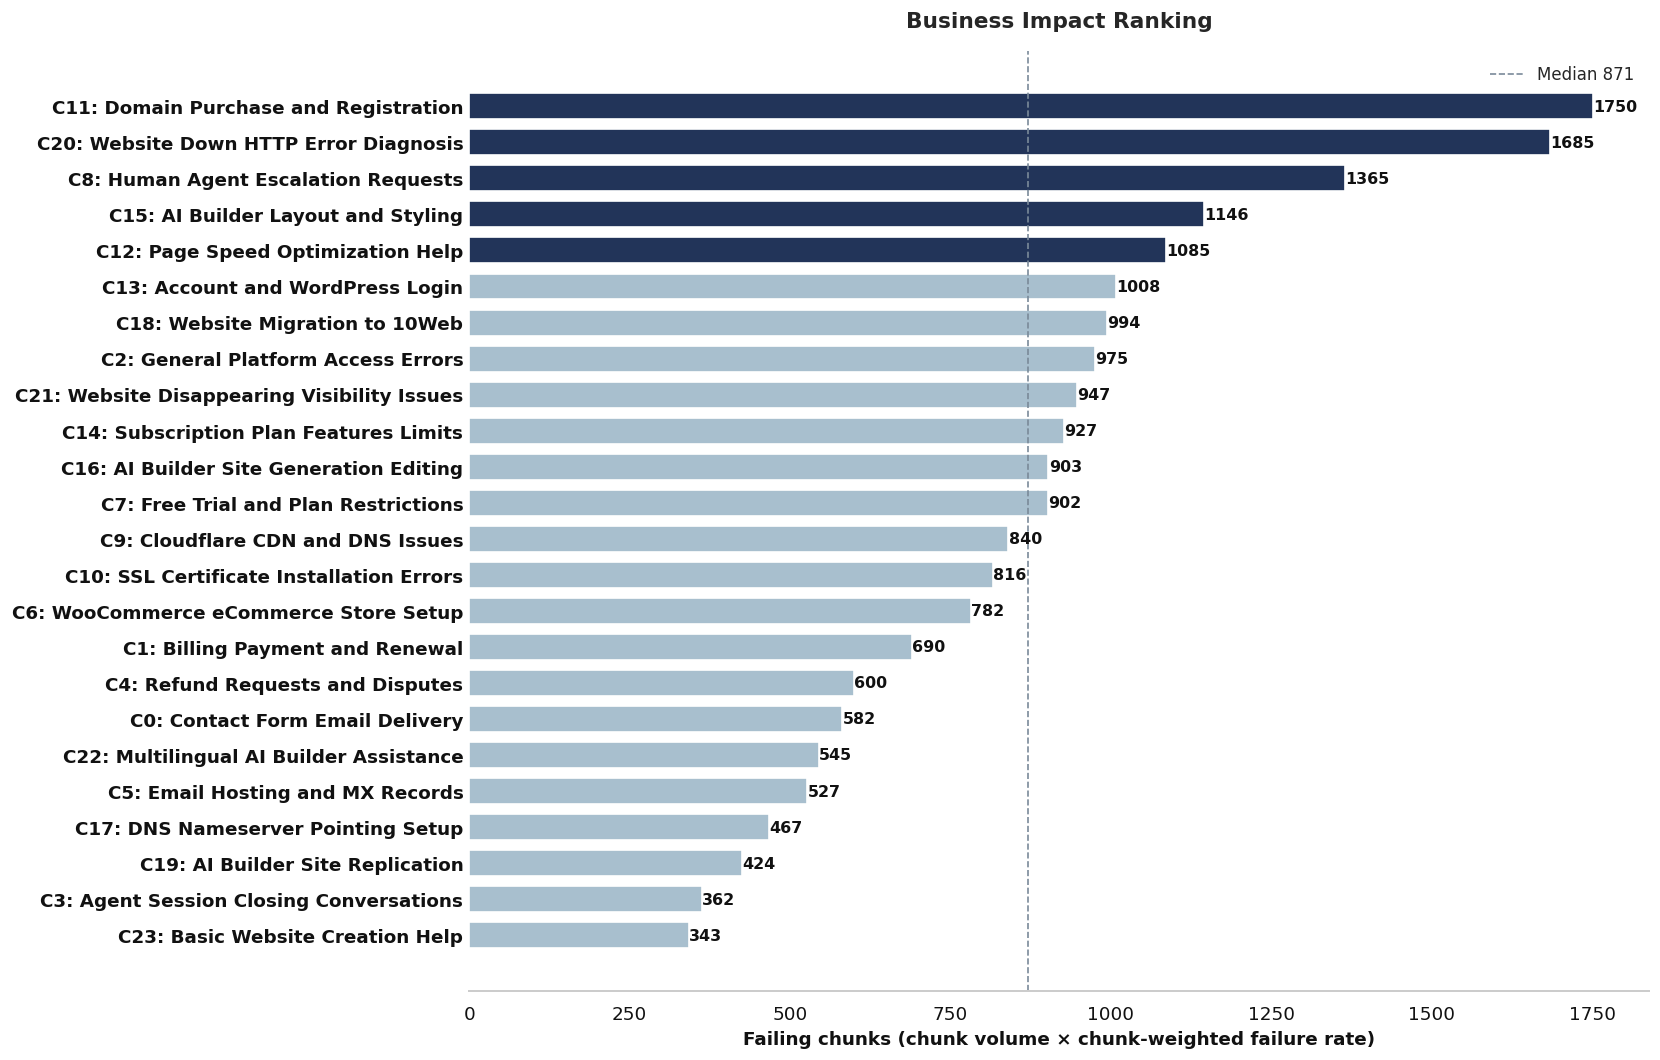

Saved: data/business_impact_ranking.png


In [7]:
NAVY     = '#223459'
STEEL    = '#A8BFCE'
BLACK    = '#111111'

impact_df = fail_rate.copy()
impact_df['failing_chunks'] = impact_df['n_chunks'] * impact_df['fail_rate'] / 100
impact_df = impact_df.sort_values('failing_chunks', ascending=False).reset_index(drop=True)
impact_df['label'] = impact_df.apply(
    lambda r: f"C{int(r['cluster_id'])}: {r['cluster_title']}", axis=1)

impact_sorted = impact_df.sort_values('failing_chunks', ascending=True)

TOP5_THRESHOLD = impact_sorted['failing_chunks'].nlargest(5).min()

cols_left = [NAVY if v >= TOP5_THRESHOLD else STEEL
             for v in impact_sorted['failing_chunks']]

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.grid(False)

ax.barh(range(len(impact_sorted)), impact_sorted['failing_chunks'],
        color=cols_left, height=0.72)

for i, val in enumerate(impact_sorted['failing_chunks']):
    ax.text(val + 0.5, i, f'{val:.0f}', va='center', fontsize=9.5,
            color=BLACK, fontweight='bold')

ax.set_yticks(range(len(impact_sorted)))
ax.set_yticklabels(impact_sorted['label'], fontsize=11, color=BLACK)
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

ax.set_xlabel('Failing chunks (chunk volume × chunk-weighted failure rate)',
              fontsize=11, color=BLACK, fontweight='bold')
ax.set_title('Business Impact Ranking', fontsize=13, fontweight='bold', pad=14)

ax.axvline(impact_sorted['failing_chunks'].median(),
           color='#7A8A99', ls='--', lw=1,
           label=f'Median {impact_sorted["failing_chunks"].median():.0f}')
ax.legend(frameon=False, fontsize=10)

ax.tick_params(axis='x', colors=BLACK, labelsize=11, length=5, width=1.2)
ax.tick_params(axis='y', colors=BLACK, labelsize=11, length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'business_impact_ranking.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Saved: data/business_impact_ranking.png')

## 3. Top keywords in failed vs successful chunks


In [8]:
failed_texts  = df_chunks[df_chunks['is_failure']]['chunk_text'].fillna('').tolist()
success_texts = df_chunks[~df_chunks['is_failure']]['chunk_text'].fillna('').tolist()

all_texts = failed_texts + success_texts
v = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2), min_df=10)
mat = v.fit_transform(all_texts)
vocab = v.get_feature_names_out()

n_fail     = len(failed_texts)
mean_fail  = mat[:n_fail].mean(axis=0).A1
mean_succ  = mat[n_fail:].mean(axis=0).A1
diff       = mean_fail - mean_succ

TOP_N = 15
over_fail = diff.argsort()[::-1][:TOP_N]
over_succ = diff.argsort()[:TOP_N][::-1]

print(f'FAILED chunks  (n={n_fail:,})  — most over-represented vs successful:')
print('  ' + ', '.join(vocab[over_fail]))
print(f'\nSUCCESSFUL chunks (n={len(success_texts):,}) — most over-represented vs failed:')
print('  ' + ', '.join(vocab[over_succ]))

FAILED chunks  (n=22,876)  — most over-represented vs successful:
  agent, connect, hear provide, query assist, clarify query, details clarify, query, sorry hear, care agent, connect customer, user exactly, direct assistance, ai sorry, prefer direct, assist better

SUCCESSFUL chunks (n=146,833) — most over-represented vs failed:
  haven heard, heard, image url, close, url url, dear, email, rate support, ai rate, support received, received, rate, user, thank, url


In [9]:
_chunks_per = df_chunks.groupby('conversation_id').size().rename('n_chunks')
_fail = df.loc[df['is_failure']].merge(_chunks_per, on='conversation_id', how='left')
_fail['n_chunks'] = _fail['n_chunks'].fillna(0).astype(int)
print('Chunks per conversation (headline-failing conversations only):')
print(_fail['n_chunks'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
print(f"Share with >5 chunks: {100 * (_fail['n_chunks'] > 5).mean():.1f}%")
print(f"Share with >7 chunks: {100 * (_fail['n_chunks'] > 7).mean():.1f}%")

Chunks per conversation (headline-failing conversations only):
count    3491.000000
mean        6.552850
std         6.266045
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
90%        13.000000
95%        17.000000
max       136.000000
Name: n_chunks, dtype: float64
Share with >5 chunks: 45.3%
Share with >7 chunks: 29.4%


Failure Signal Correlation Matrix (Phi coefficient):

                      flag_escalation  flag_negative_rating  flag_long_unresolved  flag_short_abandon
flag_escalation                 1.000                 0.166                 0.547              -0.377
flag_negative_rating            0.166                 1.000                -0.117              -0.139
flag_long_unresolved            0.547                -0.117                 1.000              -0.319
flag_short_abandon             -0.377                -0.139                -0.319               1.000

Co-occurrence counts (pairs of signals both = 1):
  escalation ∩ negative_rating: 1383 / 14033 = 9.9%
  escalation ∩ long_unresolved: 7457 / 15521 = 48.0%
  escalation ∩ short_abandon: 99 / 25873 = 0.4%
  negative_rating ∩ long_unresolved: 0 / 12052 = 0.0%
  negative_rating ∩ short_abandon: 0 / 15046 = 0.0%
  long_unresolved ∩ short_abandon: 0 / 22608 = 0.0%


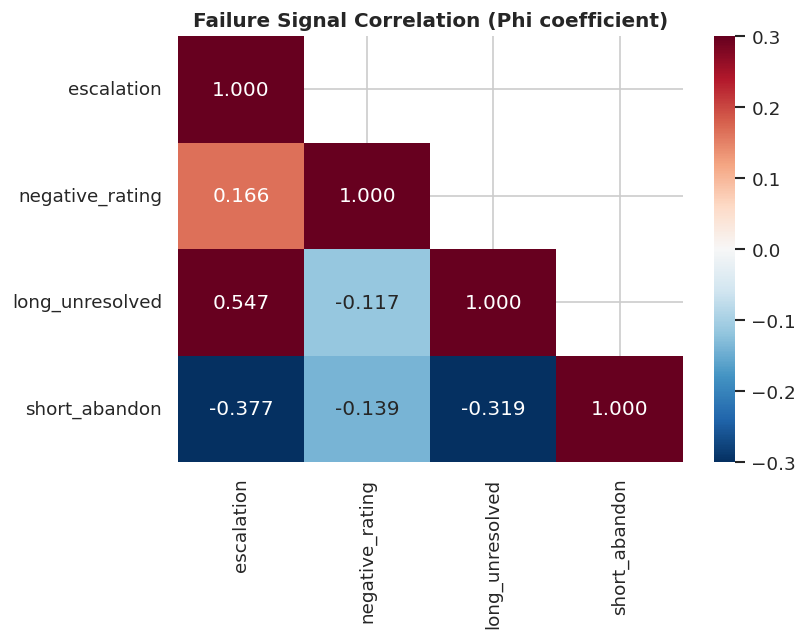

Saved: signal_correlation.png


In [10]:
import seaborn as sns

signal_cols = ['flag_escalation', 'flag_negative_rating', 'flag_long_unresolved', 'flag_short_abandon']
corr = df[signal_cols].corr()

print('Failure Signal Correlation Matrix (Phi coefficient):\n')
print(corr.round(3).to_string())

print('\nCo-occurrence counts (pairs of signals both = 1):')
for i, s1 in enumerate(signal_cols):
    for s2 in signal_cols[i+1:]:
        both = (df[s1] & df[s2]).sum()
        either = (df[s1] | df[s2]).sum()
        print(f'  {s1.replace("flag_","")} ∩ {s2.replace("flag_","")}: {both} / {either} = {100*both/max(either,1):.1f}%')

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax,
            xticklabels=[c.replace('flag_', '') for c in signal_cols],
            yticklabels=[c.replace('flag_', '') for c in signal_cols],
            vmin=-0.3, vmax=0.3)
ax.set_title('Failure Signal Correlation (Phi coefficient)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'signal_correlation.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: signal_correlation.png')


## 4. Escalation trend over time

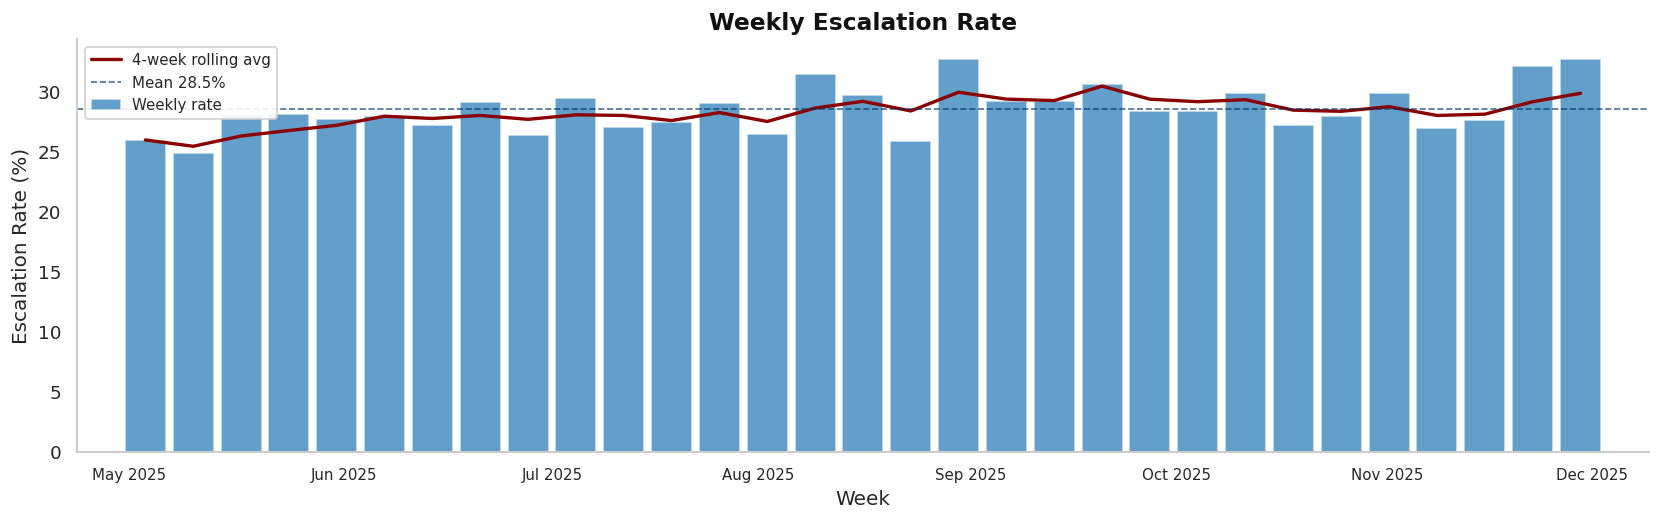

Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-d): mean=28.5%  min=24.9%  max=32.7%


In [11]:
weekly_esc = (
    df.groupby('week')
    .agg(total=('is_failure', 'count'), escalations=('flag_escalation', 'sum'))
    .assign(esc_rate=lambda d: 100 * d['escalations'] / d['total'])
    .reset_index()
)
weekly_esc['week'] = pd.to_datetime(weekly_esc['week'])
weekly_esc['rolling'] = weekly_esc['esc_rate'].rolling(4, min_periods=1).mean()
avg_esc = weekly_esc['esc_rate'].mean()

fig, ax = plt.subplots(figsize=(14, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.grid(False)
ax.bar(weekly_esc['week'], weekly_esc['esc_rate'],
       width=pd.Timedelta(days=6), alpha=0.7, label='Weekly rate')
ax.plot(weekly_esc['week'], weekly_esc['rolling'], color='darkred', lw=2,
        label='4-week rolling avg')
ax.axhline(avg_esc, color='#003366', ls='--', lw=1.0, alpha=0.7,
           label=f'Mean {avg_esc:.1f}%')
ax.set_title('Weekly Escalation Rate', fontsize=14, fontweight='bold', color='#111111')
ax.set_xlabel('Week')
ax.set_ylabel('Escalation Rate (%)')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), ha='right', fontsize=9)
x_pad = pd.Timedelta(days=10)
ax.set_xlim(weekly_esc['week'].min() - x_pad, weekly_esc['week'].max() + x_pad)
ax.legend(frameon=True, loc='upper left', framealpha=0.9,
          fontsize=9, edgecolor='#cccccc')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f'escalation_trend_{TRACK}.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f'{lbl}: mean={avg_esc:.1f}%  min={weekly_esc["esc_rate"].min():.1f}%  max={weekly_esc["esc_rate"].max():.1f}%')

## 5. Most common escalation phrases

In [12]:
esc_merge = df_chunks.merge(
    df[['conversation_id', 'flag_escalation', 'flag_negative_rating',
        'flag_long_unresolved', 'flag_short_abandon', 'is_failure']],
    on='conversation_id',
    how='left',
)
esc_texts = esc_merge[esc_merge['flag_escalation'].fillna(False)]['chunk_text'].fillna('').str.lower()

patterns = [
    ('agent', r'\bagent\b'),
    ('human', r'\bhuman\b'),
    ('live chat/support', r'live (chat|support|agent)'),
    ('speak to someone', r'speak to (someone|a person|support)'),
    ('real person', r'real person'),
    ('supervisor/manager', r'(supervisor|manager)'),
    ('escalate', r'\bescalate\b'),
    ('talk to agent', r'talk to (someone|a human|an agent|agent)'),
    ('customer service', r'customer service'),
]
n_esc_chunks = len(esc_texts)
n_esc_convs  = esc_merge.loc[esc_merge['flag_escalation'].fillna(False), 'conversation_id'].nunique()
print('Phrase match rates below are among chunks in conversations where '
      '`failure_flags.requested_agent` is true (agent-request signal from BigQuery regex on original text).')
print('They are not "% of all escalations" and not button-only "Talk to agent" UI paths without keywords.\n')
print(f'  Conversations with flag_escalation: {n_esc_convs:,} | Chunks in those conversations: {n_esc_chunks:,}')
print('\nEscalation phrase frequencies (regex on chunk_text):')
for label, pat in patterns:
    count = esc_texts.str.contains(pat, regex=True, na=False).sum()
    pct   = 100 * count / max(1, n_esc_chunks)
    print(f'  {label:30s}: {count:3d}  ({pct:.1f}% of escalation-associated chunks)')

df[['conversation_id', 'is_failure', 'flag_escalation', 'flag_negative_rating',
    'flag_long_unresolved', 'flag_short_abandon', 'client_message_count']].to_csv(RESULTS_DIR / 'failure_flags.csv', index=False)
print(f'\nFailure flags saved -> {OUT_DIR}/failure_flags.csv')


Phrase match rates below are among chunks in conversations where `failure_flags.requested_agent` is true (agent-request signal from BigQuery regex on original text).
They are not "% of all escalations" and not button-only "Talk to agent" UI paths without keywords.

  Conversations with flag_escalation: 13,171 | Chunks in those conversations: 77,977

Escalation phrase frequencies (regex on chunk_text):
  agent                         : 25843  (33.1% of escalation-associated chunks)
  human                         : 13133  (16.8% of escalation-associated chunks)
  live chat/support             : 16882  (21.6% of escalation-associated chunks)
  speak to someone              : 192  (0.2% of escalation-associated chunks)
  real person                   : 299  (0.4% of escalation-associated chunks)
  supervisor/manager            : 2536  (3.3% of escalation-associated chunks)
  escalate                      : 2238  (2.9% of escalation-associated chunks)
  talk to agent                 : 1501

## 6. Language-specific failure rates


Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-d) — Failure rate by language (n >= 30; Wilson 95% CI):
detected_language  total  fail_rate   fail_ci_lo  fail_ci_hi   esc_rate  neg_ratings
            zh-TW    107  13.084112 7.956512e+00   20.770517  21.495327           10
               sv     33   9.090909 3.140394e+00   23.572606  36.363636            2
               en  40104    7.91941 7.659129e+00    8.187750   29.97706         2060
            zh-CN    263   7.604563 4.976442e+00   11.453336  31.558935           13
               pl    123   7.317073 3.897034e+00   13.322461  19.512195            6
               ro     58   6.896552 2.714425e+00   16.433666  12.068966            1
               it    363   6.336088 4.258835e+00    9.327814    18.4573           15
               ko     65   6.153846 2.418905e+00   14.782152  24.615385            2
               es   1091   6.141155 4.864624e+00    7.725460  25.114574           39
         

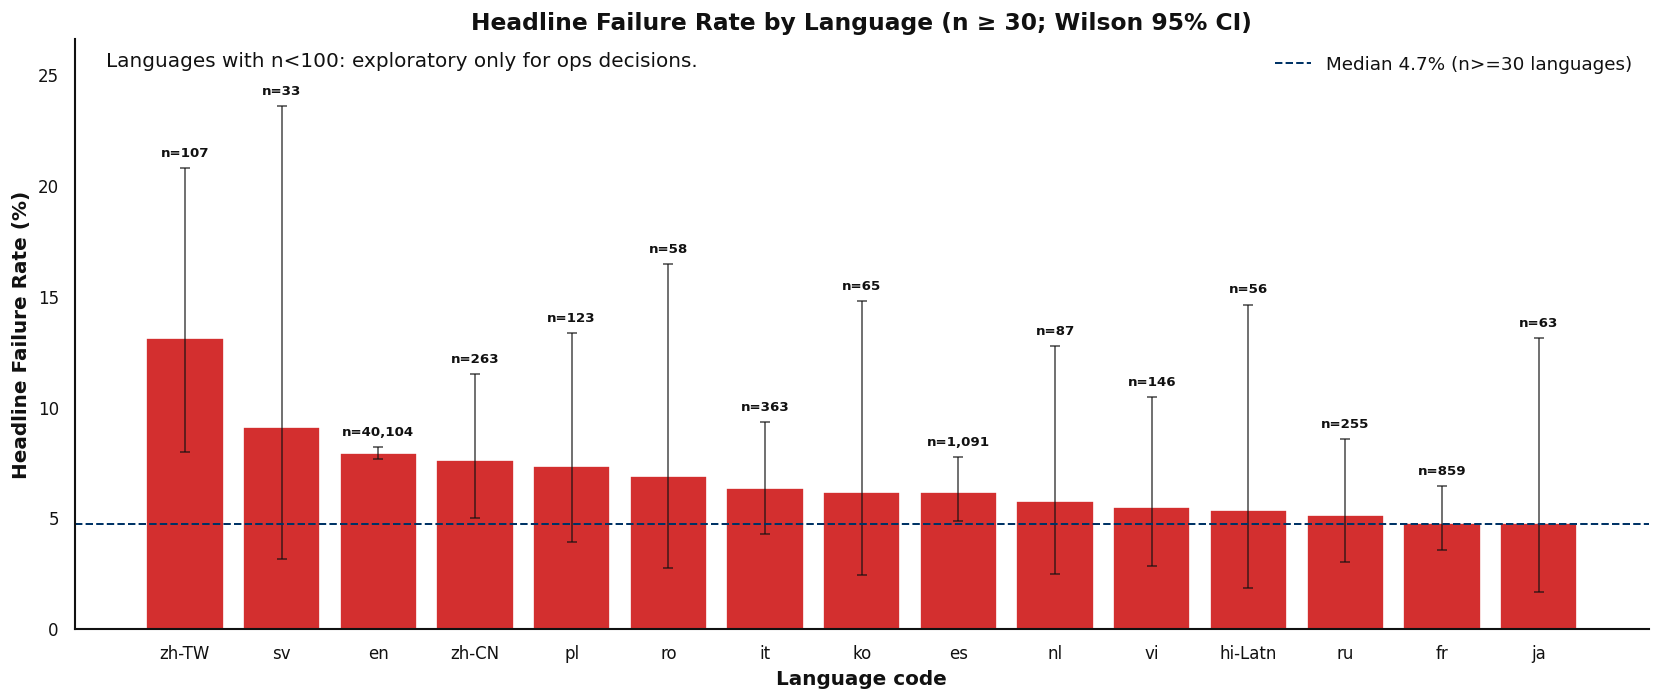

  Saved: failure_by_language_multilingual.png


In [13]:
from statsmodels.stats.proportion import proportion_confint

MIN_SAMPLE_RELIABLE = 30
MIN_HIGH_N          = 100

if 'detected_language' not in df.columns:
    raise RuntimeError("'detected_language' column missing from df — check BigQuery query in setup cell")

lang_fail = (
    df.groupby('detected_language')
    .agg(total=('is_failure', 'count'), failures=('is_failure', 'sum'),
         escalations=('flag_escalation', 'sum'), neg_ratings=('flag_negative_rating', 'sum'))
    .assign(fail_rate=lambda d: 100 * d['failures'] / d['total'],
            esc_rate=lambda d:  100 * d['escalations'] / d['total'])
    .query('total >= 5')
    .sort_values('fail_rate', ascending=False)
    .reset_index()
)
lang_fail['reliable'] = lang_fail['total'] >= MIN_SAMPLE_RELIABLE
lang_fail.to_csv(RESULTS_DIR / f'failure_by_language_{TRACK}.csv', index=False)

reliable = lang_fail[lang_fail['reliable']].copy()
low_n    = lang_fail[~lang_fail['reliable']]

if len(reliable):
    lo, hi = proportion_confint(
        reliable['failures'].values, reliable['total'].values,
        alpha=0.05, method='wilson',
    )
    reliable['fail_ci_lo'] = 100.0 * lo
    reliable['fail_ci_hi'] = 100.0 * hi

print(f'\n{lbl} — Failure rate by language (n >= {MIN_SAMPLE_RELIABLE}; Wilson 95% CI):')
if len(reliable):
    print(reliable[['detected_language', 'total', 'fail_rate', 'fail_ci_lo', 'fail_ci_hi',
                    'esc_rate', 'neg_ratings']].to_string(index=False))
else:
    print('  (none)')

if len(low_n):
    print(f'\n  Low-sample languages (n < {MIN_SAMPLE_RELIABLE}) — descriptive only:')
    print(low_n[['detected_language', 'total', 'fail_rate']].to_string(index=False))

top_langs = reliable.head(15)
if top_langs.empty:
    raise RuntimeError(f'No languages with n >= {MIN_SAMPLE_RELIABLE} — insufficient data for language chart')

BLACK = '#111111'
NAVY  = '#003366'
median_rate = reliable['fail_rate'].median()
bar_colors  = ['#d32f2f' for _ in top_langs['fail_rate']]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.grid(False)
xpos = np.arange(len(top_langs))
bars = ax.bar(xpos, top_langs['fail_rate'], color=bar_colors)
yerr_lo = top_langs['fail_rate'].values - top_langs['fail_ci_lo'].values
yerr_hi = top_langs['fail_ci_hi'].values - top_langs['fail_rate'].values
ax.errorbar(xpos, top_langs['fail_rate'], yerr=[yerr_lo, yerr_hi],
            fmt='none', ecolor=BLACK, capsize=3, alpha=0.7, linewidth=1)

ax.axhline(median_rate, color=NAVY, ls='--', lw=1.2,
           label=f'Median {median_rate:.1f}% (n>={MIN_SAMPLE_RELIABLE} languages)')
ax.set_xticks(xpos)
ax.set_xticklabels(top_langs['detected_language'], color=BLACK, fontsize=10)
ax.set_title(
    f'Headline Failure Rate by Language (n ≥ {MIN_SAMPLE_RELIABLE}; Wilson 95% CI)',
    fontsize=14, fontweight='bold', color=BLACK,
)
ax.set_xlabel('Language code', color=BLACK, fontsize=12, fontweight='bold')
ax.set_ylabel('Headline Failure Rate (%)', color=BLACK, fontsize=12, fontweight='bold')
ax.tick_params(axis='both', colors=BLACK, labelsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor(BLACK)
ax.legend(frameon=False, labelcolor=BLACK)
for xi, bar, row in zip(xpos, bars, top_langs.itertuples()):
    y_top = row.fail_ci_hi + 0.4
    ax.annotate(
        f'n={int(row.total):,}',
        (bar.get_x() + bar.get_width() / 2, y_top),
        ha='center', va='bottom', fontsize=8, color=BLACK, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                  edgecolor='none', alpha=0.85),
    )
ax.text(
    0.02, 0.98,
    f'Languages with n<{MIN_HIGH_N}: exploratory only for ops decisions.',
    transform=ax.transAxes, va='top', fontsize=12, color=BLACK,
)
ax.set_ylim(0, top_langs['fail_ci_hi'].max() + 3.0)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f'failure_by_language_{TRACK}.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f'  Saved: failure_by_language_{TRACK}.png')


## 7. Engineering escalation identification

Loaded 116 cluster cards from cluster_cards.csv


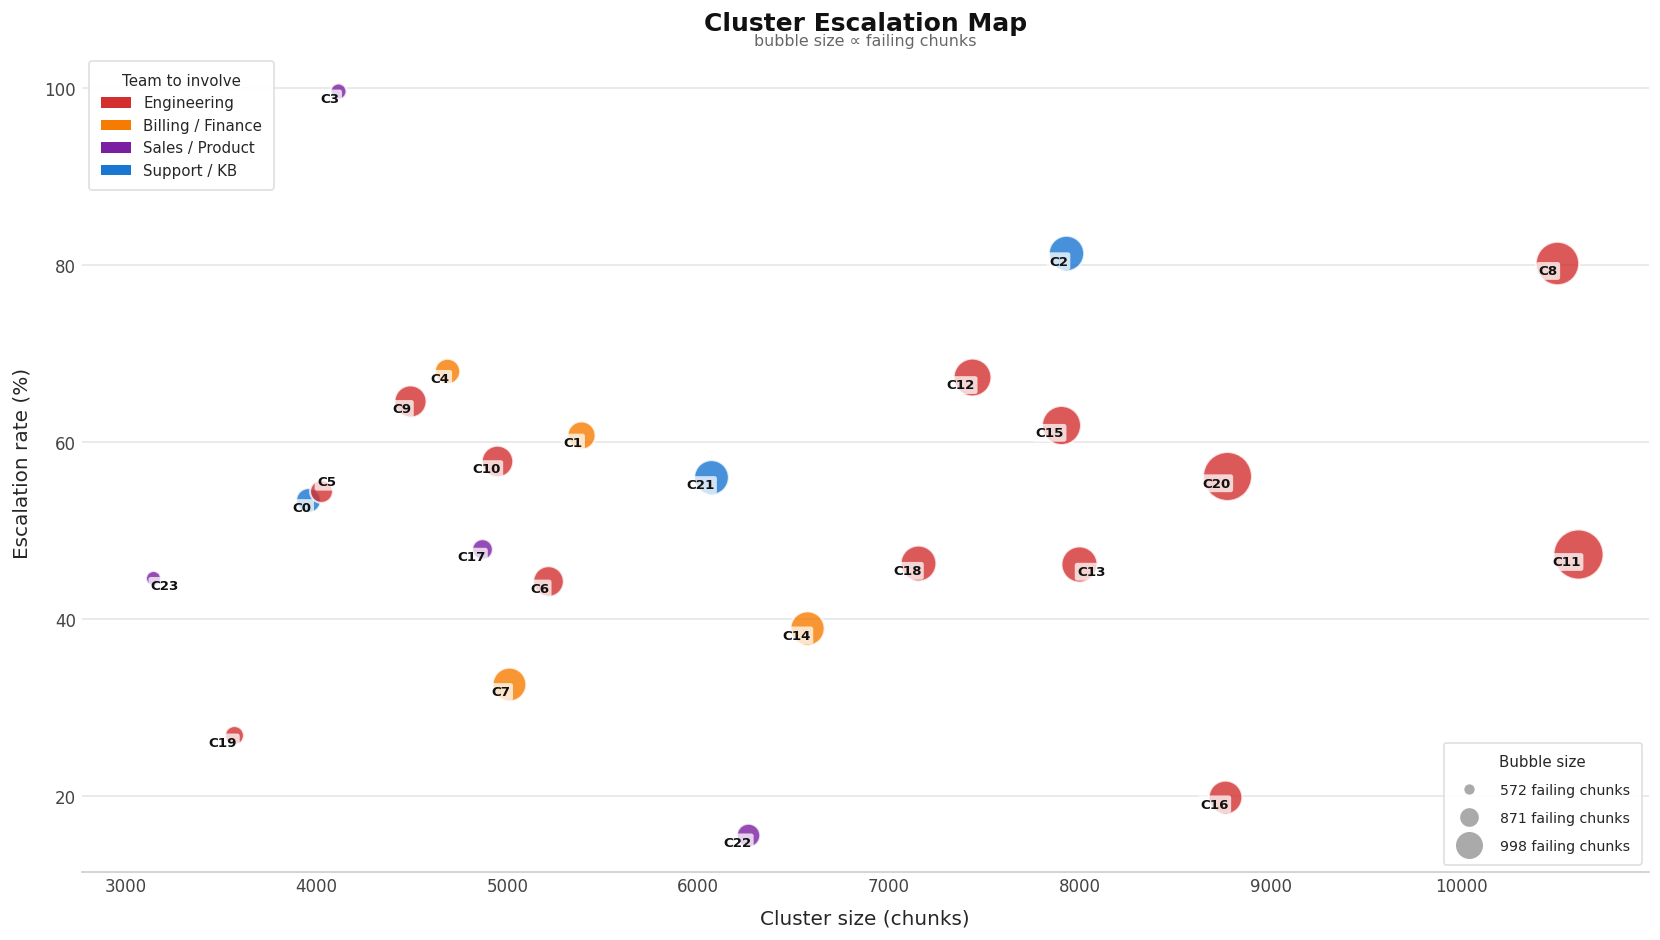

Saved: data/escalation_map.png  |  data/failure_by_cluster_with_type.csv


In [14]:
CLUSTER_ESCALATION_TYPE = {
    0: 'Support / KB', 2: 'Support / KB', 21: 'Support / KB',
    1: 'Billing / Finance', 4: 'Billing / Finance', 7: 'Billing / Finance', 14: 'Billing / Finance',
    3: 'Sales / Product', 17: 'Sales / Product', 22: 'Sales / Product', 23: 'Sales / Product',
    5: 'Engineering', 6: 'Engineering', 8: 'Engineering', 9: 'Engineering', 10: 'Engineering',
    11: 'Engineering', 12: 'Engineering', 13: 'Engineering', 15: 'Engineering', 16: 'Engineering',
    18: 'Engineering', 19: 'Engineering', 20: 'Engineering',
}

cards_file = RESULTS_DIR / 'cluster_cards.csv'
if cards_file.exists():
    cards = pd.read_csv(cards_file)
    print(f'Loaded {len(cards)} cluster cards from cluster_cards.csv')
else:
    print('[INFO] cluster_cards.csv not found. Using CLUSTER_ESCALATION_TYPE defaults.')

_cluster_csv = RESULTS_DIR / 'failure_by_cluster_multilingual.csv'
if _cluster_csv.exists():
    fail_data = pd.read_csv(_cluster_csv)
else:
    fail_data = pd.read_csv(RESULTS_DIR / 'failure_by_cluster.csv')

fail_data['escalation_type'] = fail_data['cluster_id'].map(
    CLUSTER_ESCALATION_TYPE
).fillna('Support / KB')

label_file = RESULTS_DIR / 'cluster_label_table.csv'
if label_file.exists():
    labels_df = pd.read_csv(label_file)[['cluster_id', 'gemini_label']]
    fail_data = fail_data.merge(labels_df, on='cluster_id', how='left')

fail_data['failure_impact'] = fail_data['n_chunks'] * fail_data['fail_rate'] / 100

impact_min = fail_data['failure_impact'].min()
impact_max = fail_data['failure_impact'].max()

if impact_max > impact_min:
    fail_data['bubble_size'] = (
        80
        + (fail_data['failure_impact'] - impact_min)
        / (impact_max - impact_min)
        * 820
    )
else:
    fail_data['bubble_size'] = 250

fail_data.to_csv(RESULTS_DIR / 'failure_by_cluster_with_type.csv', index=False)

type_colors = {
    'Engineering': '#d32f2f',
    'Billing / Finance': '#f57c00',
    'Sales / Product': '#7b1fa2',
    'Support / KB': '#1976d2',
}

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.yaxis.grid(True, color='#E6E6E6', linewidth=1.0, zorder=0)
ax.set_axisbelow(True)
ax.xaxis.grid(False)

for _, row in fail_data.iterrows():
    color = type_colors.get(str(row.get('escalation_type', '')), 'grey')
    ax.scatter(
        row['n_chunks'],
        row['esc_rate'],
        s=row['bubble_size'],
        color=color,
        alpha=0.80,
        edgecolor='white',
        linewidth=1.2,
        zorder=3
    )

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:
    from adjustText import adjust_text
except ImportError:
    import subprocess
    import sys
    subprocess.run([sys.executable, "-m", "pip", "install", "adjustText", "-q"], check=True)
    from adjustText import adjust_text

texts, x_pts, y_pts = [], [], []

for _, row in fail_data.iterrows():
    cid = int(row['cluster_id'])
    x, y = row['n_chunks'], row['esc_rate']
    x_pts.append(x)
    y_pts.append(y)

    txt = ax.text(
        x, y, f"C{cid}",
        fontsize=8,
        ha='center',
        va='center',
        color='#111111',
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.18',
            facecolor='white',
            edgecolor='none',
            alpha=0.75
        ),
        zorder=6
    )
    texts.append(txt)

adjust_text(
    texts,
    x=np.array(x_pts),
    y=np.array(y_pts),
    ax=ax,
    expand_points=(2.2, 2.2),
    expand_text=(1.5, 1.5),
    force_points=0.6,
    force_text=0.5,
    only_move={'points': 'xy', 'texts': 'xy'},
)

legend_elements = [
    Patch(facecolor=c, edgecolor='none', label=t)
    for t, c in type_colors.items()
]

team_legend = ax.legend(
    handles=legend_elements,
    title='Team to involve',
    title_fontsize=9,
    fontsize=9,
    loc='upper left',
    frameon=True,
    framealpha=0.92,
    edgecolor='#dddddd',
    borderpad=0.8,
)
ax.add_artist(team_legend)

size_examples = np.quantile(fail_data['failure_impact'], [0.25, 0.50, 0.75])

size_handles = [
    Line2D(
        [], [],
        linestyle='none',
        marker='o',
        markersize=ms,
        markerfacecolor='#aaaaaa',
        markeredgecolor='white',
        markeredgewidth=0.8,
        label=f'{imp:.0f} failing chunks'
    )
    for imp, ms in zip(size_examples, [7, 12, 17])
]

ax.legend(
    handles=size_handles,
    title='Bubble size',
    title_fontsize=9,
    fontsize=8.5,
    loc='lower right',
    frameon=True,
    framealpha=0.92,
    edgecolor='#dddddd',
    handletextpad=1.2,
    labelspacing=1.0,
    borderpad=0.8,
)

ax.set_xlabel('Cluster size (chunks)', fontsize=12, labelpad=8)
ax.set_ylabel('Escalation rate (%)', fontsize=12, labelpad=8)
ax.set_title(
    'Cluster Escalation Map',
    fontsize=15,
    fontweight='bold',
    color='#111111',
    pad=14
)
ax.annotate(
    'bubble size ∝ failing chunks',
    xy=(0.5, 1.01),
    xycoords='axes fraction',
    ha='center',
    fontsize=9.5,
    color='#666666'
)

ax.tick_params(axis='both', colors='#444444', labelsize=10, length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.spines['bottom'].set_linewidth(1.0)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / 'escalation_map.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
    edgecolor='none'
)
plt.show()

print('Saved: data/escalation_map.png  |  data/failure_by_cluster_with_type.csv')